## Experiment No: 5
## Experiment Title: Text Classification using Naive Bayes and Logistic Regression

**Name:** Himanshu Jadhav  
**Roll Number:** TE-32

### Step 1: Import Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)
from tabulate import tabulate

print("Libraries imported successfully.")

Libraries imported successfully.


### Step 2: Create a Sample Labeled Dataset (Spam vs Ham)

In [2]:
data = {
    "text": [
        "win a free lottery now claim your prize",
        "congratulations you won a free iphone click here",
        "urgent your account has been suspended verify now",
        "get cheap loans instantly no credit check",
        "claim your free gift card today limited offer",
        "you have been selected for a cash prize",
        "hi how are you doing today",
        "let's meet for lunch tomorrow afternoon",
        "can you send me the report by evening",
        "happy birthday hope you have a great day",
        "the meeting has been rescheduled to monday",
        "thank you for your help with the project",
        "are we still on for the movie tonight",
        "please review the attached document",
        "free entry to win a brand new car",
        "exclusive deal just for you claim now",
        "reminder your bill payment is due tomorrow",
        "let's catch up over coffee this weekend",
        "your package has been shipped and will arrive soon",
        "congratulations you are the lucky winner today"
    ],
    "label": [
        "spam", "spam", "spam", "spam", "spam",
        "spam", "ham", "ham", "ham", "ham",
        "ham", "ham", "ham", "ham", "spam",
        "spam", "ham", "ham", "ham", "spam"
    ]
}

df = pd.DataFrame(data)
print("Dataset shape:", df.shape)
print(tabulate(df.head(10), headers='keys', tablefmt='psql'))

Dataset shape: (20, 2)
+----+---------------------------------------------------+---------+
|    | text                                              | label   |
|----+---------------------------------------------------+---------|
|  0 | win a free lottery now claim your prize           | spam    |
|  1 | congratulations you won a free iphone click here  | spam    |
|  2 | urgent your account has been suspended verify now | spam    |
|  3 | get cheap loans instantly no credit check         | spam    |
|  4 | claim your free gift card today limited offer     | spam    |
|  5 | you have been selected for a cash prize           | spam    |
|  6 | hi how are you doing today                        | ham     |
|  7 | let's meet for lunch tomorrow afternoon           | ham     |
|  8 | can you send me the report by evening             | ham     |
|  9 | happy birthday hope you have a great day          | ham     |
+----+---------------------------------------------------+---------+


### Step 3: Preprocess and Split the Data

In [3]:
df["text"] = df["text"].str.lower()

X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.3, random_state=33, stratify=df["label"]
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test     set size: {X_test.shape[0]} samples")

Training set size: 14 samples
Test     set size: 6 samples


### STep 4: TF-IDF Feature Extraction

In [4]:
vectorizer    = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print("TF-IDF feature matrix shape (train):", X_train_tfidf.shape)
print("Sample feature names:", vectorizer.get_feature_names_out()[:10])

TF-IDF feature matrix shape (train): (14, 71)
Sample feature names: ['account' 'afternoon' 'and' 'are' 'arrive' 'been' 'birthday' 'by' 'can'
 'cash']


### Step 5: Train Naive Bayes Classifier

In [5]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)
print("Naive Bayes PredictionsL: ", list(nb_predictions))
print("Actual Labels           : ", list(y_test))

Naive Bayes PredictionsL:  [np.str_('ham'), np.str_('ham'), np.str_('ham'), np.str_('spam'), np.str_('spam'), np.str_('ham')]
Actual Labels           :  ['ham', 'spam', 'ham', 'spam', 'spam', 'ham']


### Step 6: Train Logistic Regression Classifier

In [6]:
lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf, y_train)

lr_predictions = lr_model.predict(X_test_tfidf)
print("Logistic Regression Predictions : ", list(lr_predictions))
print("Actual Labels                   : ", list(y_test))

Logistic Regression Predictions :  ['ham', 'ham', 'ham', 'ham', 'spam', 'ham']
Actual Labels                   :  ['ham', 'spam', 'ham', 'spam', 'spam', 'ham']


### Step 7: Confusion Matrices

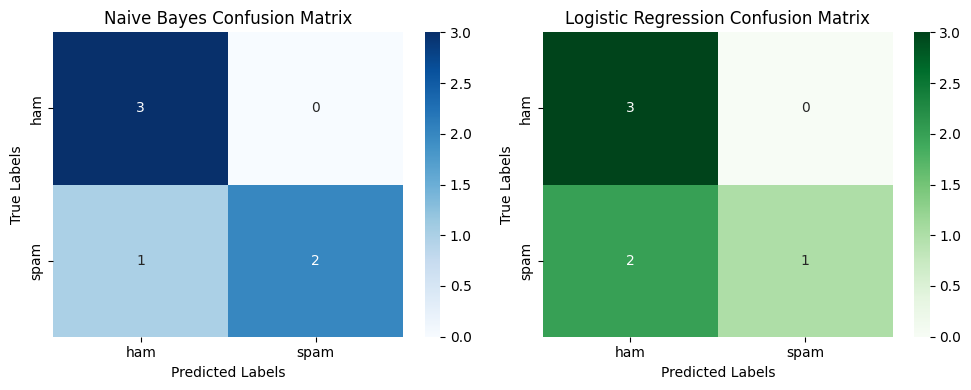

In [7]:
labels = ["ham", "spam"]

nb_cm  = confusion_matrix(y_test, nb_predictions, labels=labels)
lr_cm  = confusion_matrix(y_test, lr_predictions, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(nb_cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("Naive Bayes Confusion Matrix")
axes[0].set_xlabel("Predicted Labels")
axes[0].set_ylabel("True Labels")

sns.heatmap(lr_cm, annot=True, fmt="d", cmap="Greens", xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("Logistic Regression Confusion Matrix")
axes[1].set_xlabel("Predicted Labels")
axes[1].set_ylabel("True Labels")

plt.tight_layout()
plt.show()

### Step 8: Evaluation Metrics Comparison

In [8]:
def get_metrics(y_true, y_pred):
    return {
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label="spam"),
        "Recall"   : recall_score(y_true, y_pred, pos_label="spam"),
        "F1 Score" : f1_score(y_true, y_pred, pos_label="spam")
    }

nb_metrics = get_metrics(y_test, nb_predictions)
lr_metrics = get_metrics(y_test, lr_predictions)

metrics_df = pd.DataFrame([nb_metrics, lr_metrics], index=["Naive Bayes", "Logistic Regression"])
print("\nClassification Metrics:")
print(tabulate(metrics_df, headers='keys', tablefmt='fancy_grid'))


Classification Metrics:
╒═════════════════════╤════════════╤═════════════╤══════════╤════════════╕
│                     │   Accuracy │   Precision │   Recall │   F1 Score │
╞═════════════════════╪════════════╪═════════════╪══════════╪════════════╡
│ Naive Bayes         │   0.833333 │           1 │ 0.666667 │        0.8 │
├─────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│ Logistic Regression │   0.666667 │           1 │ 0.333333 │        0.5 │
╘═════════════════════╧════════════╧═════════════╧══════════╧════════════╛


### Final Output 

In [9]:
def pretty_classification_report(y_true, y_pred, labels, model_name):
    report_dict = classification_report(y_true, y_pred, target_names=labels, output_dict=True)
    
    df = pd.DataFrame(report_dict).T.round(3)
    
    print(f"\nClassification Report for {model_name}:")
    print(tabulate(df, headers='keys', tablefmt='fancy_grid'))

pretty_classification_report(y_test, nb_predictions, labels, "Naive Bayes")
pretty_classification_report(y_test, lr_predictions, labels, "Logistic Regression")



Classification Report for Naive Bayes:
╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ ham          │       0.75  │    1     │      0.857 │     3     │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ spam         │       1     │    0.667 │      0.8   │     3     │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │       0.833 │    0.833 │      0.833 │     0.833 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ macro avg    │       0.875 │    0.833 │      0.829 │     6     │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ weighted avg │       0.875 │    0.833 │      0.829 │     6     │
╘══════════════╧═════════════╧══════════╧════════════╧═══════════╛

Classification Report for Logistic Regression:
╒══════════════╤═════════════╤══════════╤